## Step 1: The forward process = Noise scheduler


We first need to build the inputs for our model, which are more and more noisy images. Instead of doing this sequentially, we can use the closed form provided in the papers to calculate the image for any of the timesteps individually.

In [24]:
# ======== 1. Define linear beta schedule =
# This creates a linearly increasing noise schedule (βₜ)
# from 'start' to 'end' over all diffusion timesteps.
def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start, end, timesteps)

In [25]:

# ======== 2. Helper: get a value from a list at specific time step
# Given a tensor of values (like βₜ or αₜ), and a batch of time indices t,
# this picks the correct value for each sample in the batch.
def get_index_from_list(vals, t, x_shape):
      batch_size = t.shape[0]
      out = vals.gather(-1, t.cpu())
      return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

In [26]:
# ======== 3. Forward diffusion (add noise)
# Adds noise to an input image x₀ based on the chosen time step t.
# This simulates the forward diffusion process q(xₜ | x₀).
def forward_diffusion_sample(x_0, t, device="cpu"):
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x_0.shape
    )
    # Return the noisy image: sqrt(ᾱₜ) * x₀ + sqrt(1-ᾱₜ) * noise
    return sqrt_alphas_cumprod_t.to(device) * x_0.to(device) \
         + sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device), noise.to(device)


In [27]:
# ======== 4. Precompute constants for the diffusion process ========

In [28]:
T= 600  # diffusion steps
betas = linear_beta_schedule(timesteps=T)  # noise schedule (βₜ)

# αₜ = 1 - βₜ  → how much of the original signal remains each step
alphas = 1. - betas

# ᾱₜ = cumulative product of all αₜ up to step t
alphas_cumprod = torch.cumprod(alphas, axis=0)

# ᾱₜ₋₁ (previous cumulative product)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

# Useful precomputed terms for faster sampling
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)  # 1 / √αₜ
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)  # √ᾱₜ
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)  # √(1 - ᾱₜ)

# Posterior variance for reverse process (used later)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

In [29]:
from torchvision import transforms
from torch.utils.data import DataLoader
from PIL import Image

# ----------------------------
# 1) Config
# ----------------------------
IMG_SIZE   = 64        # Most important fix
BATCH_SIZE = 8         # Fits Colab GPU
T          = 300       # Faster & safer


In [30]:
def ensure_pil_rgb(im):

    if isinstance(im, list):
        if len(im) != 1:
            raise TypeError(f"Expected single image, got list len={len(im)}")
        im = im[0]
    if isinstance(im, Image.Image):
        return im.convert("RGB")
    if torch.is_tensor(im):
        return to_pil_image(im.detach().cpu().squeeze()).convert("RGB")
    arr = np.array(im) if not isinstance(im, np.ndarray) else im
    arr = np.squeeze(arr)
    if arr.ndim == 3 and arr.shape[0] in (1,3,4) and arr.shape[-1] not in (1,3,4):
        arr = np.transpose(arr, (1,2,0))   # CHW -> HWC
    if arr.ndim == 2:                      #  HxW -> 3 c
        arr = np.stack([arr, arr, arr], axis=-1)
    return Image.fromarray(arr).convert("RGB")

data_transform = transforms.Compose([
    transforms.Lambda(ensure_pil_rgb),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                 # -> [0,1]
    transforms.Lambda(lambda t: t*2 - 1),  # -> [-1,1]
])


In [31]:
# ----------------------------
# 2) Dataset
# ----------------------------
def apply_transform(examples):

    imgs = examples["image"]
    if isinstance(imgs, list):
        examples["pixel_values"] = [data_transform(ensure_pil_rgb(im)) for im in imgs]
    else:
        examples["pixel_values"] = data_transform(ensure_pil_rgb(imgs))
    return examples


data_hf = concatenate_datasets([train, test])
data_t  = data_hf.with_transform(apply_transform)

def collate_fn(batch):
    xs = torch.stack([b["pixel_values"] for b in batch])            # [B,3,H,W]
    ys = torch.tensor([int(b["label"]) for b in batch], dtype=torch.long)
    return xs, ys

dataloader = DataLoader(
    data_t,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    collate_fn=collate_fn,
    num_workers=0,
    persistent_workers=False,
)

# check
xb, yb = next(iter(dataloader))
print("Batch ok:", xb.shape, xb.min().item(), xb.max().item())  # [B,3,IMG,IMG], ~[-1,1]



Batch ok: torch.Size([8, 3, 64, 64]) -1.0 1.0


In [32]:
# ----------------------------
# Reverse/denorm + viewers  (ADD THIS)
# ----------------------------

def tensor_to_numpy_0_1(x):
    """x in [-1,1], [C,H,W] or [1,C,H,W] -> NumPy HWC in [0,1]."""
    if x.ndim == 4: x = x[0]
    x = x.detach().cpu().clamp(-1, 1)
    if x.ndim == 2: x = x.unsqueeze(0)
    if x.shape[0] == 1: x = x.repeat(3, 1, 1)  # gray -> fake RGB
    x = (x + 1) / 2.0
    return x.permute(1, 2, 0).numpy()

def tensor_to_pil(x):
    arr01 = tensor_to_numpy_0_1(x)
    return Image.fromarray((arr01 * 255).astype(np.uint8))

def show_tensor_image(x, title=None):
    plt.imshow(tensor_to_numpy_0_1(x))
    if title: plt.title(title)
    plt.axis('off')


In [33]:
from torchvision.utils import make_grid


def show_tensor_batch(xb, n=25, cols=5, title=None):
    xb = xb[:n].detach().cpu().clamp(-1, 1)
    grid = make_grid((xb + 1)/2, nrow=cols)      # -> [C,H,W] in [0,1]
    grid = grid.permute(1, 2, 0).numpy()         # -> HWC
    plt.figure(figsize=(2.2*cols, 2.2*((n+cols-1)//cols)))
    if title: plt.title(title)
    plt.imshow(grid); plt.axis('off'); plt.tight_layout(); plt.show()

Batch shape: torch.Size([8, 3, 64, 64]) range: (-1.0, 1.0)


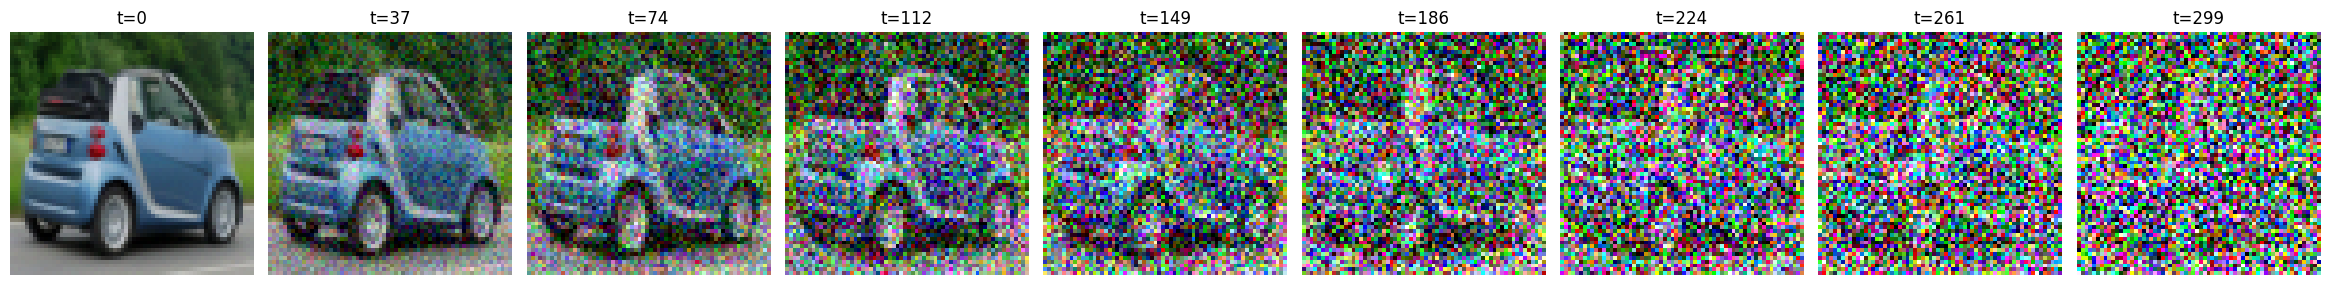

In [34]:
# Example usage with your loop:
xb, yb = next(iter(dataloader))
print("Batch shape:", xb.shape, "range:", (xb.min().item(), xb.max().item()))

num_images = 9
steps = torch.linspace(0, T-1, steps=num_images, dtype=torch.long)

x0 = xb[:1].to(device)
plt.figure(figsize=(2.6*num_images, 3))
for i, idx in enumerate(steps.tolist(), 1):
    t = torch.tensor([idx], dtype=torch.long, device=device)
    x_t, _ = forward_diffusion_sample(x0, t, device=device)
    plt.subplot(1, num_images, i); plt.title(f"t={int(idx)}")
    show_tensor_image(x_t)
plt.tight_layout(); plt.show()


In [1]:
# # ----------------------------
# # Model
# # --------------------------- 

import torch.nn as nn
class Net(nn.Module):
  def __init__(self, in_ch, out_ch, tim_dim, up=False):
    super().__init__()

    self.time_mlp = nn.Linear(tim_dim, out_ch)

    if up:
      self.conv1 = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
      self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
    else:
      self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
      self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)

    self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1)
    self.norm1 = nn.BatchNorm2d(out_ch)
    self.norm2 = nn.BatchNorm2d(out_ch)
    self.relu = nn.ReLU()

  def forward(self, x, t):
    x = self.norm1(self.relu(self.conv1(x)))
    t = self.relu(self.time_mlp(t))
    t = t[:, :, None, None]
    x = x + t
    x = self.norm2(self.relu(self.conv2(x)))
    return self.transform(x)


In [36]:
import math
class SinsoidalPosEmbeddings(nn.Module):

  def __init__(self,dim):
    super().__init__()
    self.dim = dim

  def forward(self,t):
    device = t.device
    h = self.dim//2

    embd = math.log(10000) / (h - 1)
    embd = torch.exp(torch.arange(h, device=device) * -embd)

    embd = t[:,None] * embd[None,:]
    embd = torch.cat((embd.sin(), embd.cos()), dim=-1)

    return embd


In [37]:
import torch
import torch.nn as nn
import math

# ------------------------------
# Time Embedding
# ------------------------------
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half = self.dim // 2
        freq = torch.exp(-math.log(10000) * torch.arange(half, device=device) / (half - 1))
        emb = t[:, None] * freq[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


# ------------------------------
# Basic Block
# ------------------------------
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.BatchNorm2d(out_ch)
        self.norm2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        h = self.relu(self.norm1(self.conv1(x)))
        t = self.time_mlp(t)
        h = h + t[:, :, None, None]
        h = self.relu(self.norm2(self.conv2(h)))
        return h


# ------------------------------
# CORRECT FULL U-NET
# ------------------------------
class SimpleUNet(nn.Module):
    def __init__(self, img_ch=3, time_dim=256):
        super().__init__()

        # time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Down
        self.down1 = Block(img_ch, 64, time_dim)
        self.down2 = Block(64, 128, time_dim)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bot1 = Block(128, 256, time_dim)
        self.bot2 = Block(256, 128, time_dim)

        # Up
        self.up1 = nn.ConvTranspose2d(128, 128, 2, stride=2)
        self.up_block1 = Block(128+128, 64, time_dim)

        self.up2 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.up_block2 = Block(64+64, 64, time_dim)

        self.out = nn.Conv2d(64, img_ch, 1)

    def forward(self, x, t):

        t = self.time_mlp(t)

        # Down
        x1 = self.down1(x, t)
        x2 = self.down2(self.pool(x1), t)

        # Bottleneck
        b = self.bot1(self.pool(x2), t)
        b = self.bot2(b, t)

        # Up
        u1 = self.up1(b)
        u1 = torch.cat([u1, x2], dim=1)
        u1 = self.up_block1(u1, t)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, x1], dim=1)
        u2 = self.up_block2(u2, t)

        return self.out(u2)


In [38]:
model = SimpleUNet()
print("Num params: ", sum(p.numel() for p in model.parameters()))
model

Num params:  2215043


SimpleUNet(
  (time_mlp): Sequential(
    (0): SinusoidalPosEmb()
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): ReLU()
  )
  (down1): Block(
    (time_mlp): Linear(in_features=256, out_features=64, bias=True)
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (down2): Block(
    (time_mlp): Linear(in_features=256, out_features=128, bias=True)
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, aff

In [39]:
# ------------------------------
# Sampling
# ------------------------------

@torch.no_grad()
def sample_timestep(x, t, model):
    """
    calls the model to predict the noise residual and returns the denoised image
    """
    betas_t = get_index_from_list(betas, t, x.shape)  # Get the noise value β for the timestep t, and reshape it so it matches the batch shape.

    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )

    sqrt_recip_alphas_t = get_index_from_list(sqrt_recip_alphas, t, x.shape)

    # Call model (current image - noise prediction)
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )
    posterior_variance_t = get_index_from_list(posterior_variance, t, x.shape)

    if t == 0:
        # As pointed out by Luis Pereira (see YouTube comment)
        # The t's are offset from the t's in the paper
        return model_mean
    else:
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise

In [43]:
@torch.no_grad()
def sample_plot_image():
    # Sample noise
    img_size = IMG_SIZE
    img = torch.randn((1, 3, img_size, img_size), device=device)
    plt.figure(figsize=(15,15))
    plt.axis('off')
    num_images = 10
    stepsize = int(T/num_images)

    for i in range(0,T)[::-1]:
        t = torch.full((1,), i, device=device, dtype=torch.long)
        img = sample_timestep(img, t,model)
        # Edit: This is to maintain the natural range of the distribution
        img = torch.clamp(img, -1.0, 1.0)
        if i % stepsize == 0:
            plt.subplot(1, num_images, int(i/stepsize)+1)
            show_tensor_image(img.detach().cpu())
    plt.show()

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# ------------------------------
# Training
# ------------------------------
def train_diffusion(model, dataloader, epochs, lr, device="cuda", sample_every=1):
    """
    Full training loop for diffusion model
    Predicts noise ε_θ(x_t, t) and minimizes MSE(ε_pred, ε_true)
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    model.train()

    for epoch in range(1, epochs + 1):
        total_loss = 0
        loop = tqdm(dataloader, desc=f"Epoch {epoch}/{epochs}")

        for xb, yb in loop:
            xb = xb.to(device)

            # Sample random t for each image
            t = torch.randint(0, T, (xb.size(0),), device=device).long()

            # Forward diffusion (x_t, noise)
            x_t, noise = forward_diffusion_sample(xb, t, device=device)

            # Predict noise with model
            noise_pred = model(x_t, t)

            # MSE loss
            loss = mse(noise_pred, noise)
            total_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loop.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(dataloader)
        print(f"\n# Epoch {epoch} — Avg Loss: {avg_loss:.6f}")

        # Sampling
        if epoch % sample_every == 0:
            print(f"Sampling at epoch {epoch}")
            sample_plot_image()

    print("\n--- Training Completed ---")


Using device: cuda

... Starting training ...


Epoch 1/20: 100%|██████████| 2023/2023 [02:49<00:00, 11.91it/s, loss=0.083]



# Epoch 1 — Avg Loss: 0.136684


Epoch 2/20: 100%|██████████| 2023/2023 [02:47<00:00, 12.10it/s, loss=0.0962]



# Epoch 2 — Avg Loss: 0.090175
Sampling at epoch 2


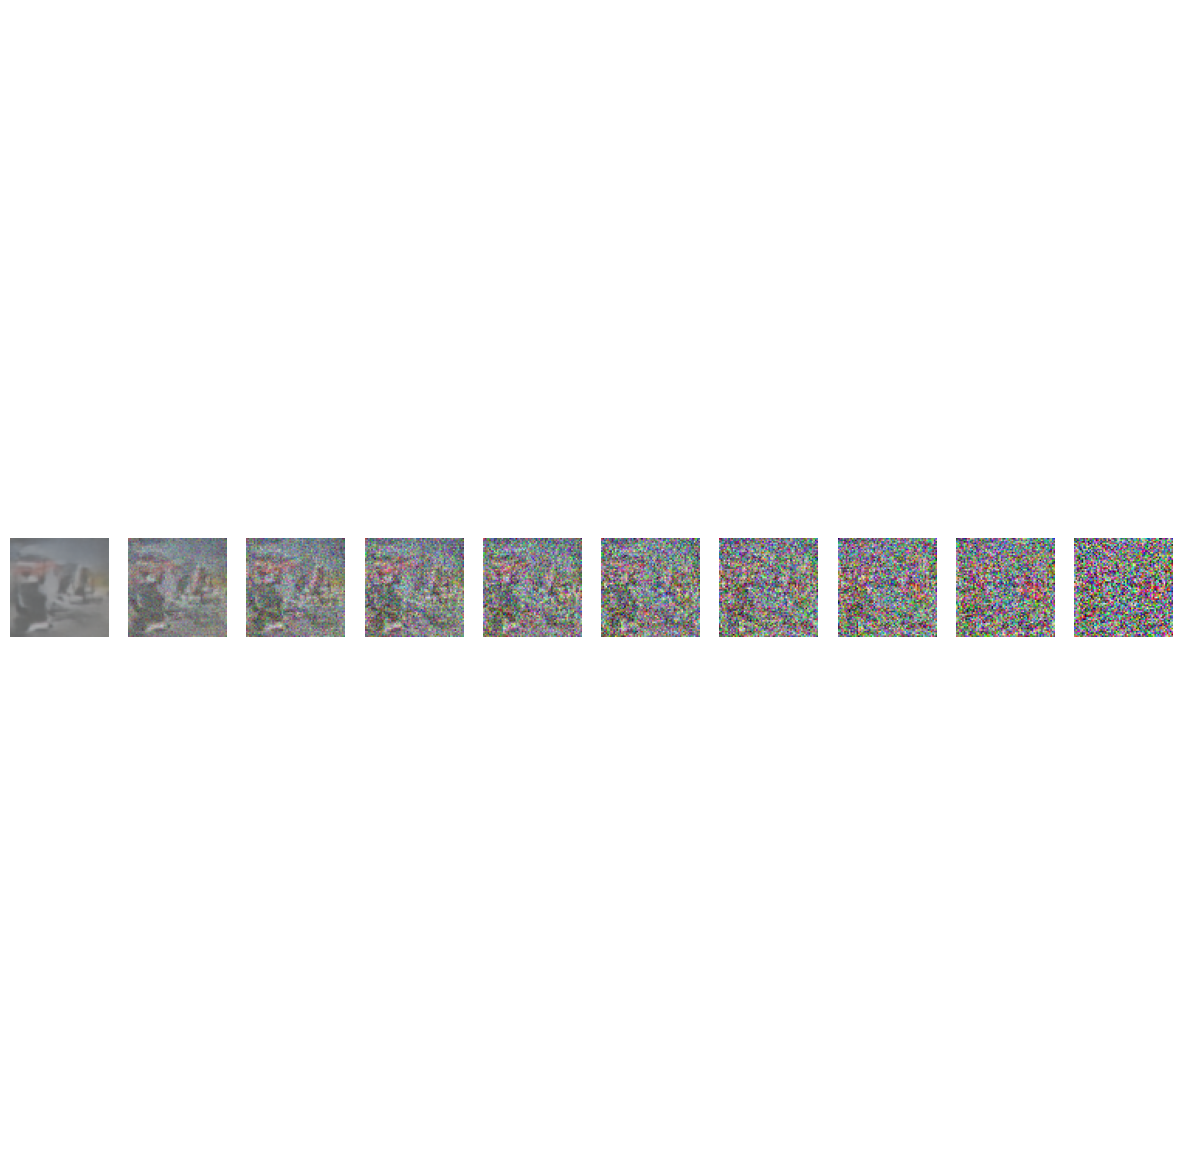

Epoch 3/20: 100%|██████████| 2023/2023 [02:57<00:00, 11.39it/s, loss=0.0664]



# Epoch 3 — Avg Loss: 0.083119


Epoch 4/20: 100%|██████████| 2023/2023 [02:55<00:00, 11.50it/s, loss=0.0517]



# Epoch 4 — Avg Loss: 0.079310
Sampling at epoch 4


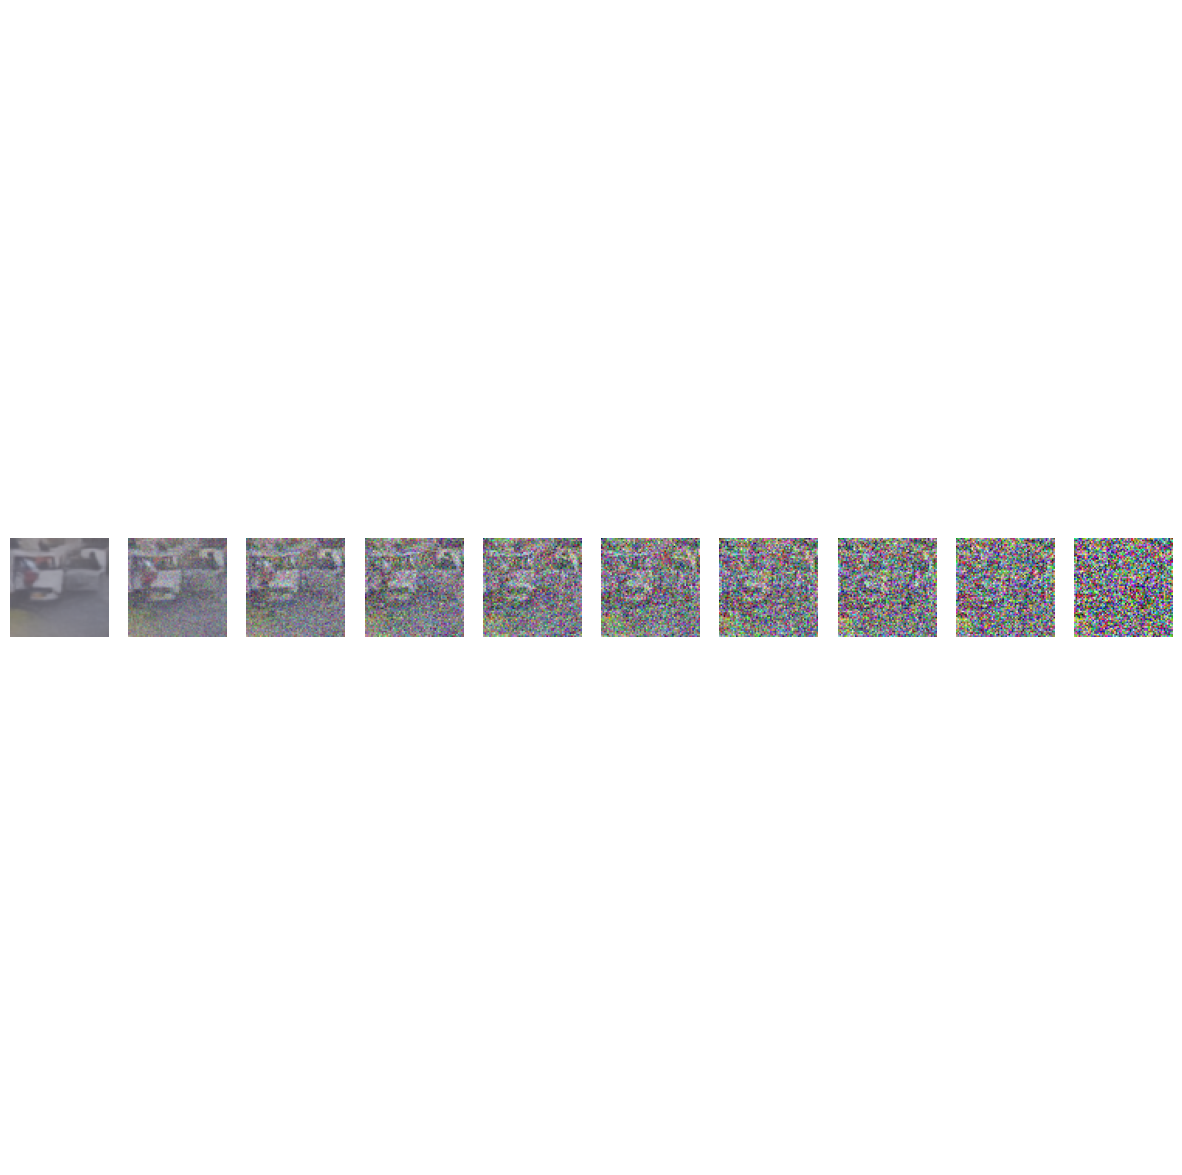

Epoch 5/20: 100%|██████████| 2023/2023 [03:00<00:00, 11.20it/s, loss=0.0383]



# Epoch 5 — Avg Loss: 0.074973


Epoch 6/20: 100%|██████████| 2023/2023 [02:58<00:00, 11.35it/s, loss=0.0508]



# Epoch 6 — Avg Loss: 0.074071
Sampling at epoch 6


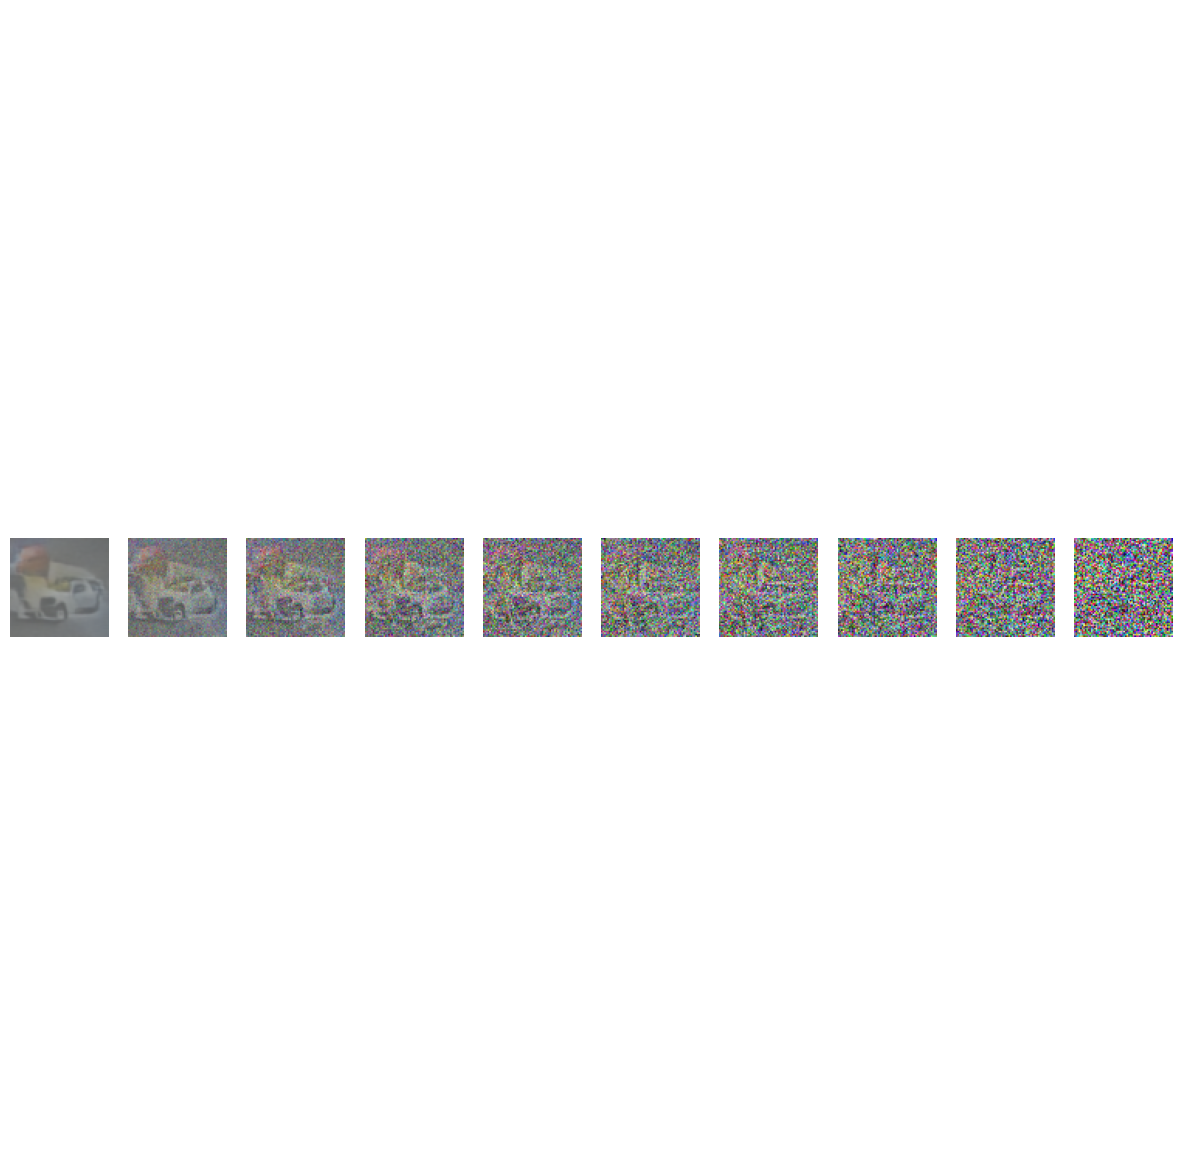

Epoch 7/20: 100%|██████████| 2023/2023 [03:04<00:00, 10.98it/s, loss=0.0681]



# Epoch 7 — Avg Loss: 0.071374


Epoch 8/20: 100%|██████████| 2023/2023 [03:03<00:00, 11.00it/s, loss=0.0599]



# Epoch 8 — Avg Loss: 0.070773
Sampling at epoch 8


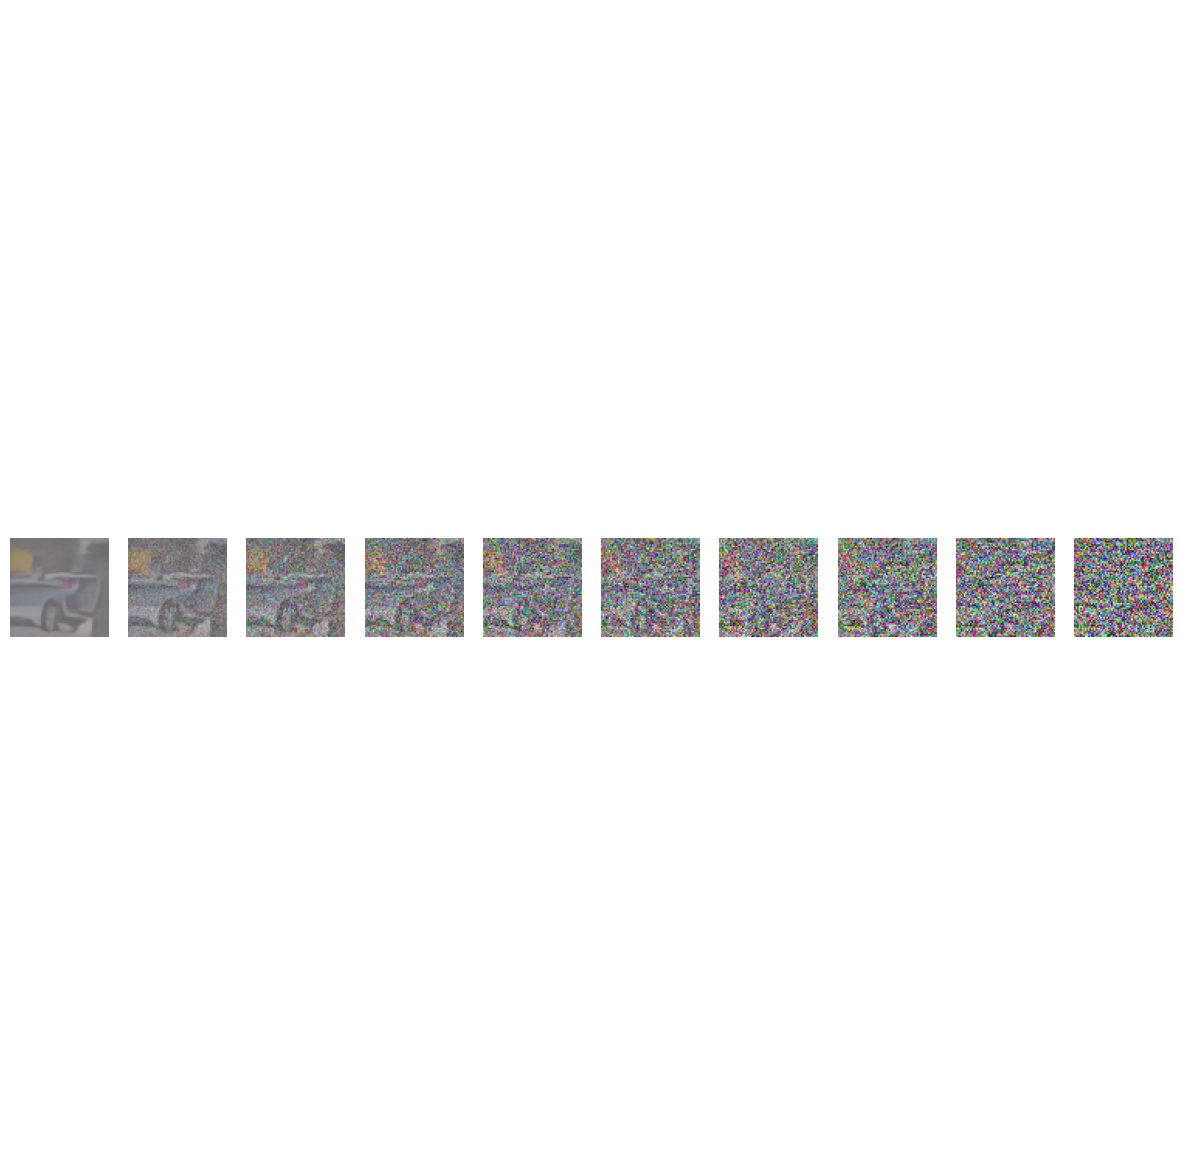

Epoch 9/20: 100%|██████████| 2023/2023 [03:09<00:00, 10.67it/s, loss=0.168]



# Epoch 9 — Avg Loss: 0.069364


Epoch 10/20: 100%|██████████| 2023/2023 [03:11<00:00, 10.58it/s, loss=0.0811]



# Epoch 10 — Avg Loss: 0.070137
Sampling at epoch 10


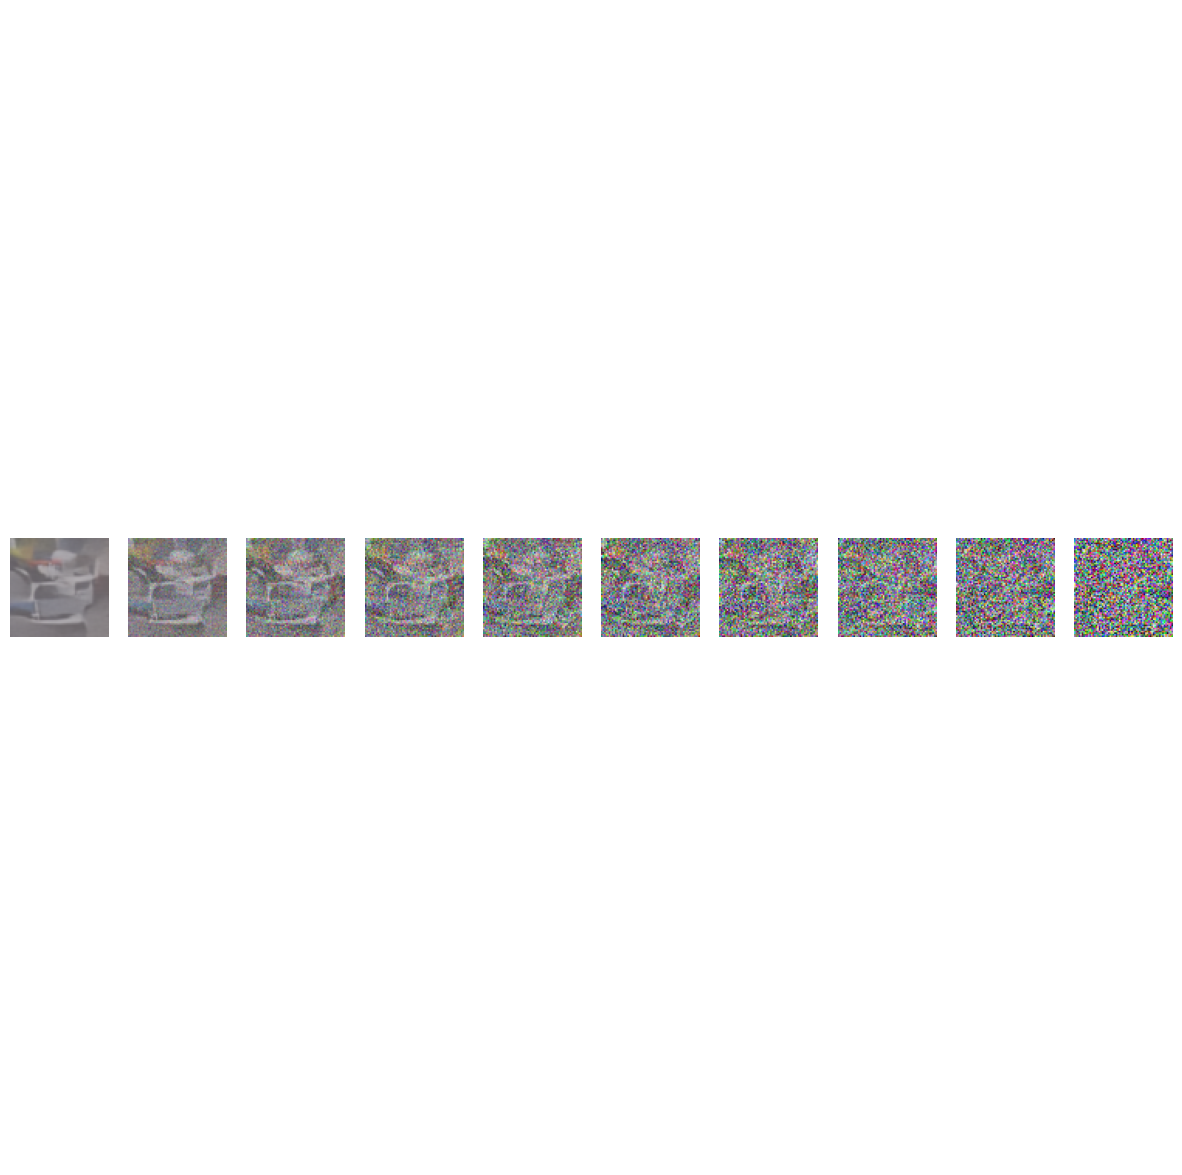

Epoch 11/20: 100%|██████████| 2023/2023 [03:16<00:00, 10.28it/s, loss=0.088]



# Epoch 11 — Avg Loss: 0.068512


Epoch 12/20: 100%|██████████| 2023/2023 [03:17<00:00, 10.26it/s, loss=0.0804]



# Epoch 12 — Avg Loss: 0.068321
Sampling at epoch 12


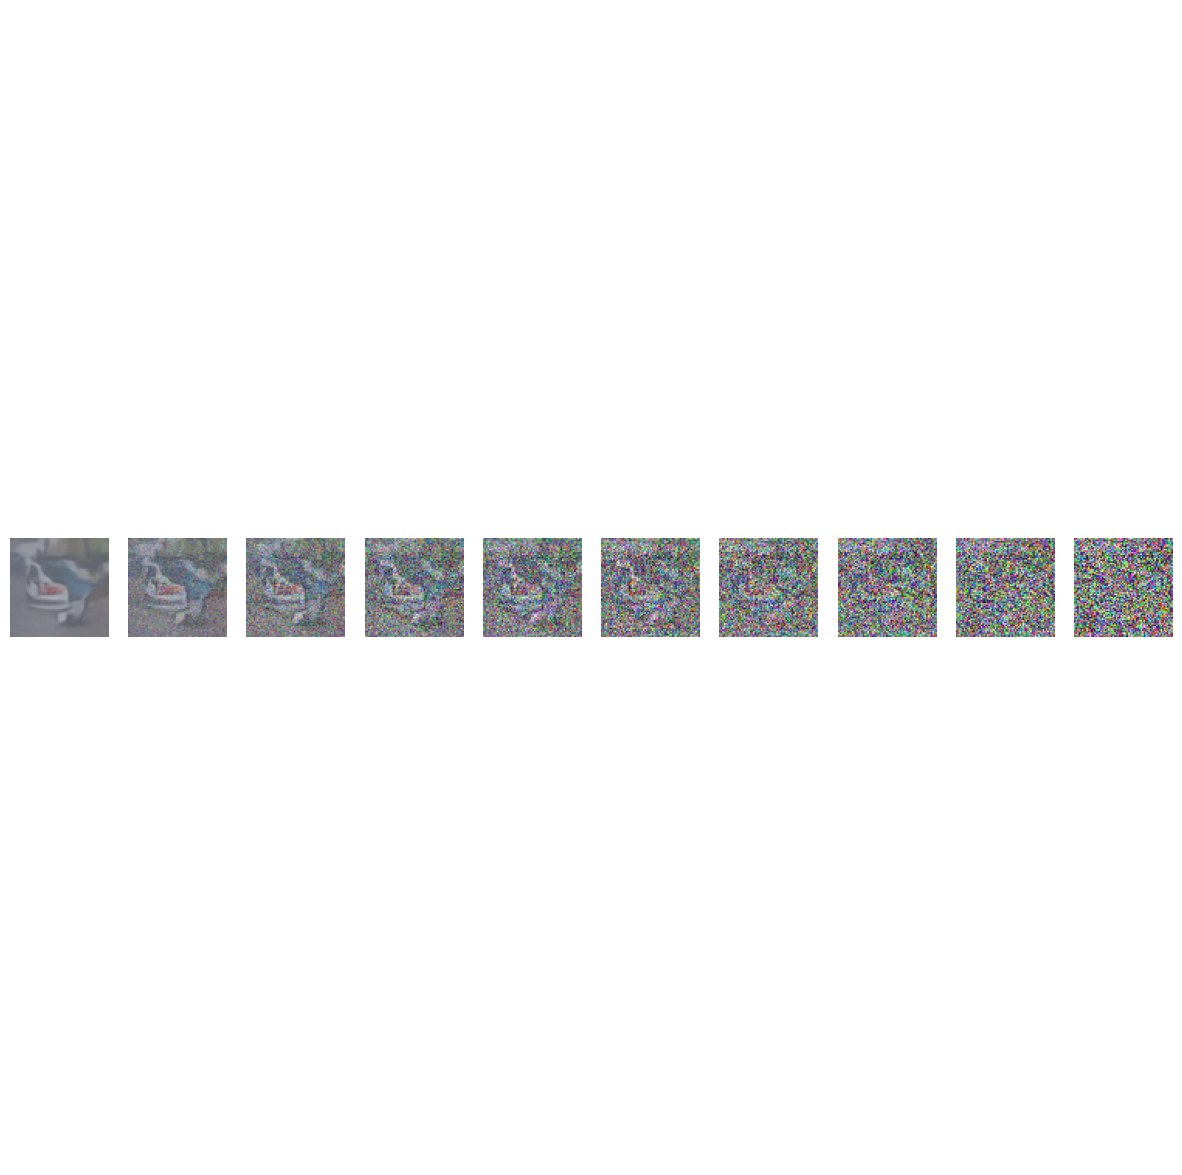

Epoch 13/20: 100%|██████████| 2023/2023 [03:24<00:00,  9.91it/s, loss=0.0405]



# Epoch 13 — Avg Loss: 0.067650


Epoch 14/20: 100%|██████████| 2023/2023 [03:25<00:00,  9.83it/s, loss=0.065]



# Epoch 14 — Avg Loss: 0.067088
Sampling at epoch 14


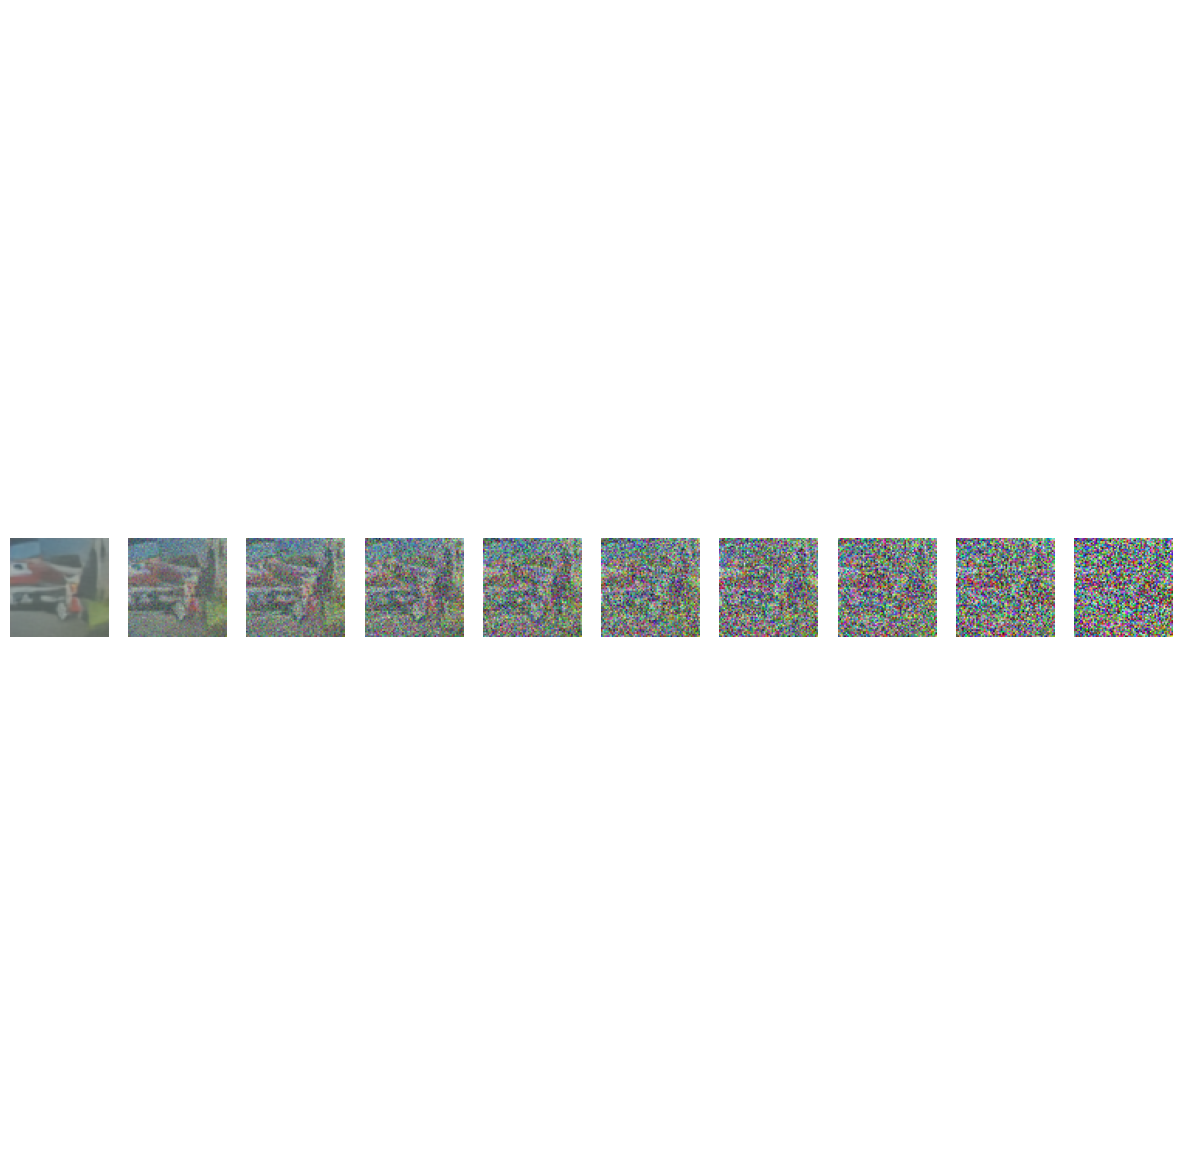

Epoch 15/20: 100%|██████████| 2023/2023 [03:30<00:00,  9.63it/s, loss=0.0237]



# Epoch 15 — Avg Loss: 0.067167


Epoch 16/20: 100%|██████████| 2023/2023 [03:29<00:00,  9.65it/s, loss=0.0673]



# Epoch 16 — Avg Loss: 0.065409
Sampling at epoch 16


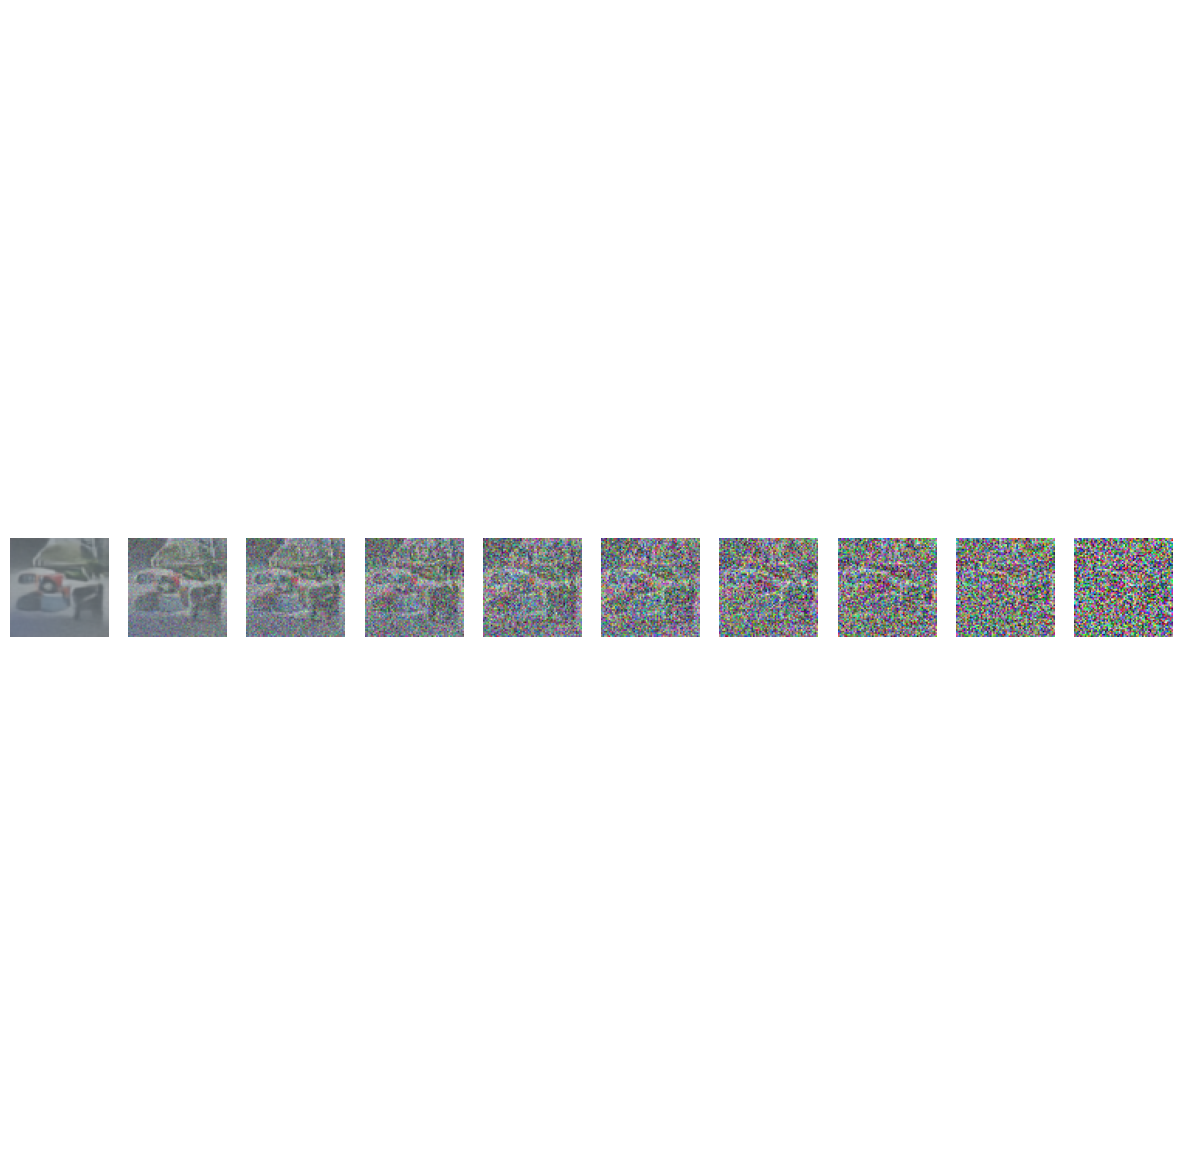

Epoch 17/20: 100%|██████████| 2023/2023 [03:34<00:00,  9.43it/s, loss=0.064]



# Epoch 17 — Avg Loss: 0.067057


Epoch 18/20: 100%|██████████| 2023/2023 [03:35<00:00,  9.40it/s, loss=0.032]



# Epoch 18 — Avg Loss: 0.066707
Sampling at epoch 18


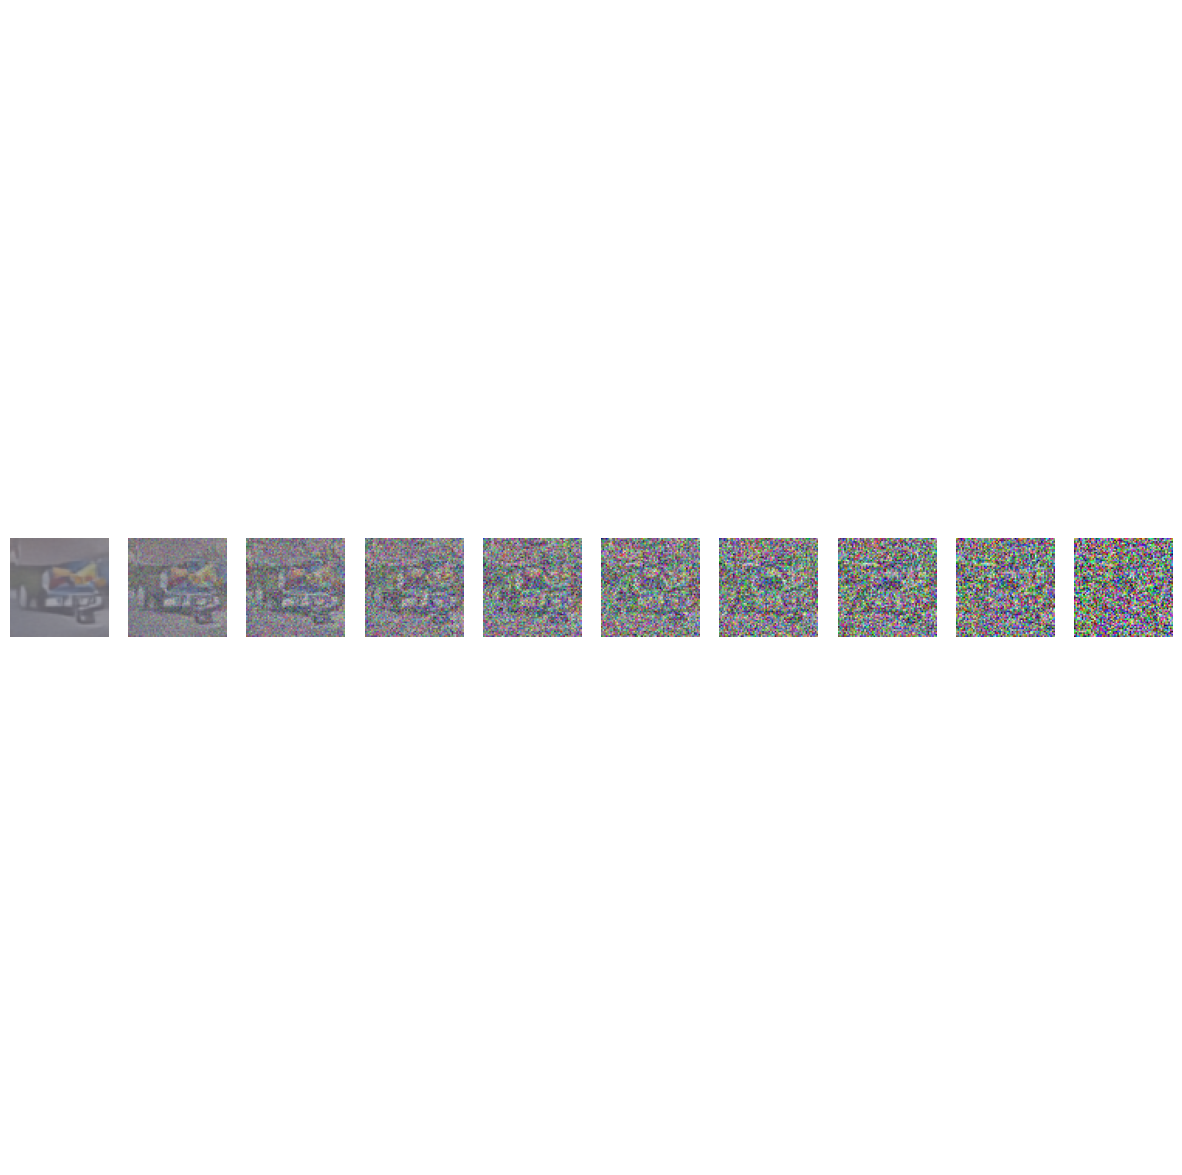

Epoch 19/20: 100%|██████████| 2023/2023 [03:36<00:00,  9.35it/s, loss=0.0761]



# Epoch 19 — Avg Loss: 0.064985


Epoch 20/20: 100%|██████████| 2023/2023 [03:32<00:00,  9.52it/s, loss=0.0777]



# Epoch 20 — Avg Loss: 0.064746
Sampling at epoch 20


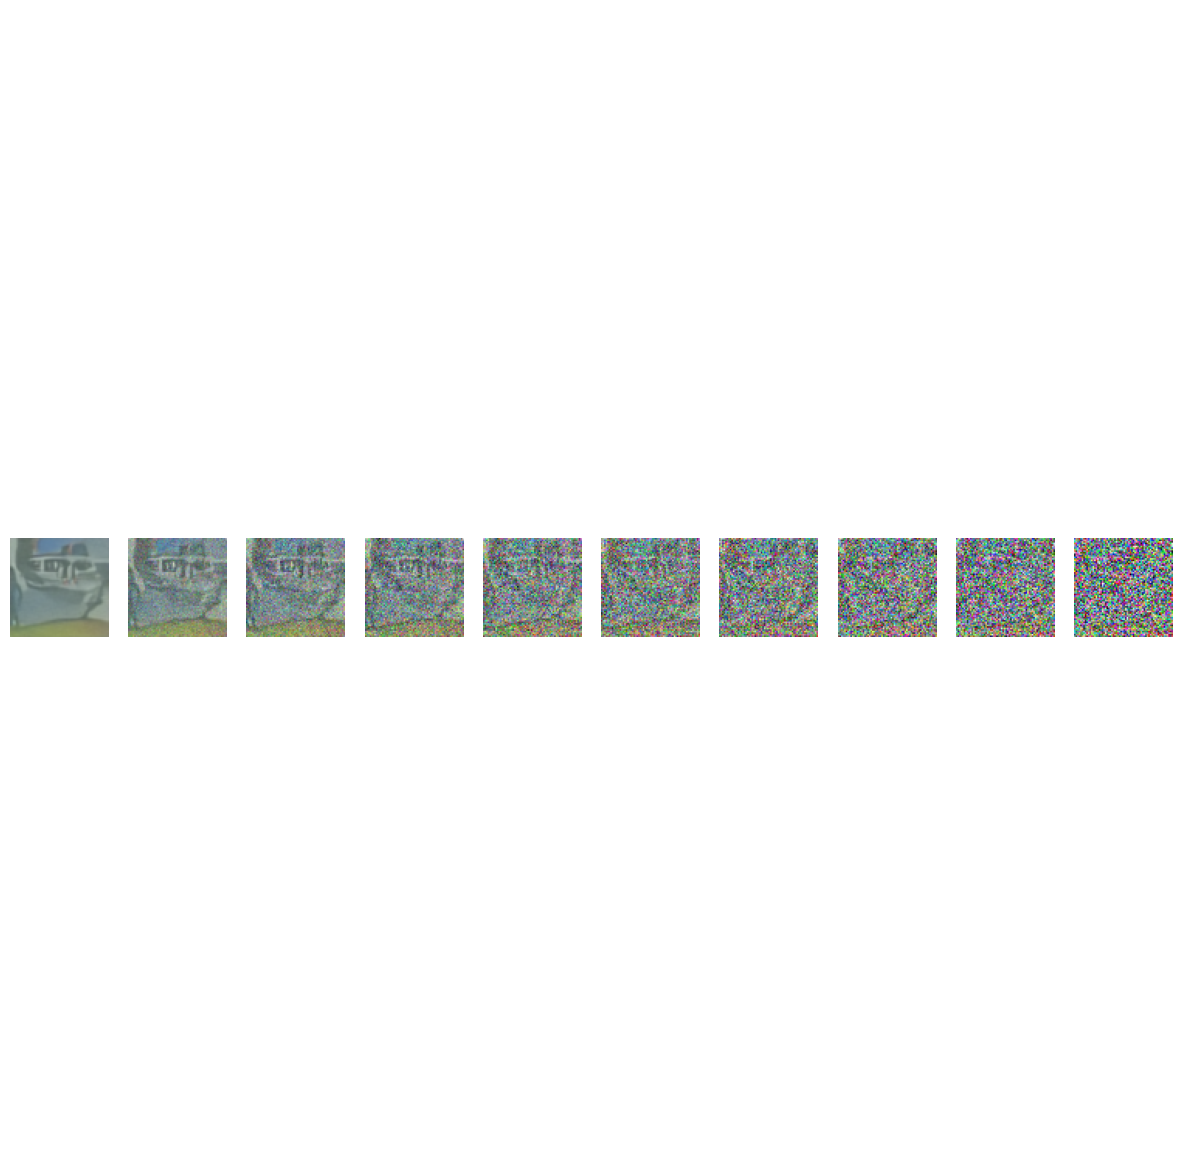


--- Training Completed ---


In [45]:
# ============================================
# 3. RUN TRAINING  — with quick pipeline test
# ============================================
import torch, gc

# free GPU memory
gc.collect()
torch.cuda.empty_cache()


# ---- MAIN ----
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Using device:", device)

    model = SimpleUNet().to(device)


    EPOCHS = 20
    LR = 1e-4

    print("\n... Starting training ...\n")

    train_diffusion(
        model=model,
        dataloader=dataloader,
        epochs=EPOCHS,
        lr=LR,
        device=device,
        sample_every=2     # sample every 2 epochs
    )
